In [1]:
# Task 3 – MNIST Digit Recognition (CNN)

## Problem
#Build a robust handwritten digit recognition model using the MNIST dataset (28×28 grayscale digits 0–9). The goal is to design, train, and evaluate a convolutional neural network (CNN) that achieves high accuracy and demonstrates good understanding of model performance and interpretability.

## Objectives
#- Load and preprocess the MNIST dataset (normalization, reshaping, one-hot encoding).
#- Train a simple baseline model and an improved CNN model.
#- Use data augmentation and callbacks (EarlyStopping, ReduceLROnPlateau) to stabilize training.
#- Evaluate performance using accuracy, confusion matrix, and classification report.
#- Visualize misclassified examples and use Grad‑CAM for basic interpretability.
#- Compare baseline vs advanced model in terms of accuracy, parameters, and training time.


In [2]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize


In [3]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print("Training Shape:", X_train.shape)


Training Shape: (60000, 28, 28, 1)


In [4]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)


In [5]:
model = keras.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])


In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 26, 26, 32)        128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 11, 11, 64)        256       
 chNormalization)                                                
                                                        

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)


In [8]:
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=128),
    epochs=20,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop, lr_reduce]
)


Epoch 1/20
469/469 [==============================] - 140s 288ms/step - loss: 0.3106 - accuracy: 0.9049 - val_loss: 0.3289 - val_accuracy: 0.8982 - lr: 0.0010
Epoch 2/20
469/469 [==============================] - 153s 326ms/step - loss: 0.1115 - accuracy: 0.9679 - val_loss: 0.0547 - val_accuracy: 0.9829 - lr: 0.0010
Epoch 3/20
469/469 [==============================] - 145s 310ms/step - loss: 0.0858 - accuracy: 0.9752 - val_loss: 0.0740 - val_accuracy: 0.9798 - lr: 0.0010
Epoch 4/20
469/469 [==============================] - 148s 316ms/step - loss: 0.0717 - accuracy: 0.9791 - val_loss: 0.0371 - val_accuracy: 0.9891 - lr: 0.0010
Epoch 5/20
469/469 [==============================] - 74s 157ms/step - loss: 0.0637 - accuracy: 0.9820 - val_loss: 0.0278 - val_accuracy: 0.9902 - lr: 0.0010
Epoch 6/20
469/469 [==============================] - 82s 174ms/step - loss: 0.0596 - accuracy: 0.9824 - val_loss: 0.0746 - val_accuracy: 0.9793 - lr: 0.0010
Epoch 7/20
469/469 [============================

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print("Final Test Accuracy:", test_accuracy)


313/313 [==============================] - 5s 16ms/step - loss: 0.0136 - accuracy: 0.9953
Final Test Accuracy: 0.9952999949455261


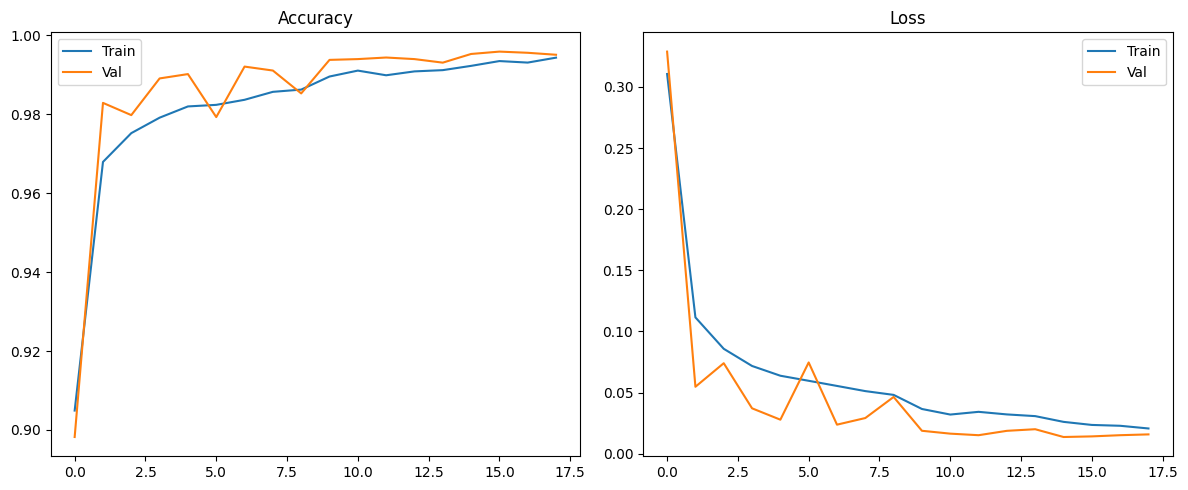

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()


313/313 [==============================] - 5s 14ms/step


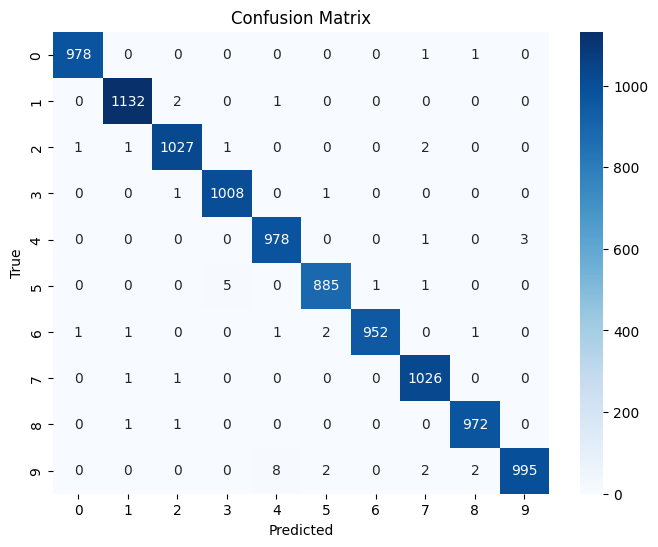

In [11]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [12]:
print(classification_report(y_test, y_pred_classes))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      1.00       958
           7       0.99      1.00      1.00      1028
           8       1.00      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [13]:
# The learning curves show that training and validation accuracy converge around ~99.5% with no severe overfitting, and validation loss does not diverge from training loss.


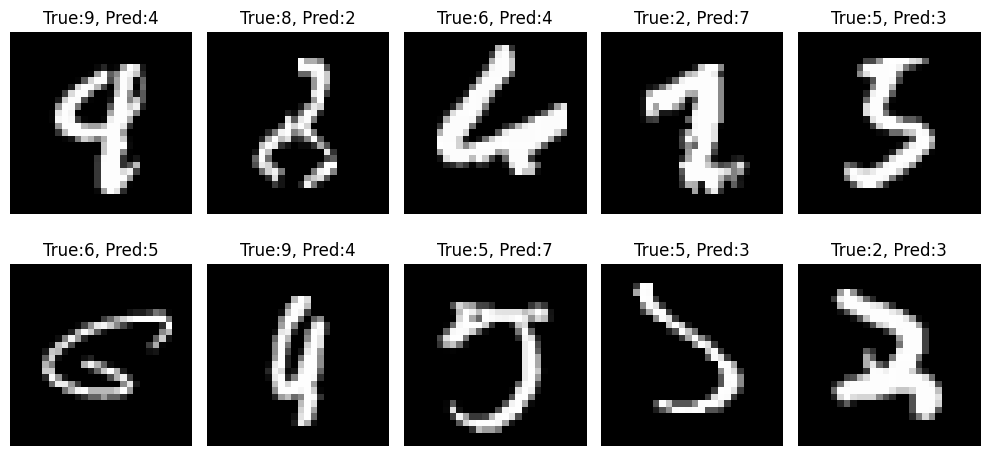

In [14]:
wrong = np.where(y_pred_classes != y_test)[0]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[wrong[i]].reshape(28,28), cmap='gray')
    plt.title(f"True:{y_test[wrong[i]]}, Pred:{y_pred_classes[wrong[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [15]:
def build_basic_model():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [16]:
basic_model = build_basic_model()

basic_history = basic_model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

basic_acc = basic_model.evaluate(X_test, y_test_cat)[1]
advanced_acc = test_accuracy


Epoch 1/5
469/469 [==============================] - 16s 32ms/step - loss: 0.2179 - accuracy: 0.9378 - val_loss: 0.0810 - val_accuracy: 0.9757
Epoch 2/5
469/469 [==============================] - 15s 32ms/step - loss: 0.0687 - accuracy: 0.9798 - val_loss: 0.0576 - val_accuracy: 0.9812
Epoch 3/5
469/469 [==============================] - 15s 32ms/step - loss: 0.0478 - accuracy: 0.9856 - val_loss: 0.0517 - val_accuracy: 0.9822
Epoch 4/5
469/469 [==============================] - 15s 33ms/step - loss: 0.0349 - accuracy: 0.9894 - val_loss: 0.0485 - val_accuracy: 0.9844
Epoch 5/5
313/313 [==============================] - 3s 10ms/step - loss: 0.0407 - accuracy: 0.9868


In [17]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Basic CNN", "Advanced CNN"],
    "Test Accuracy": [basic_acc, advanced_acc]
})

comparison


,Model,Test Accuracy
0,Basic CNN,0.9868
1,Advanced CNN,0.9953


In [18]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()


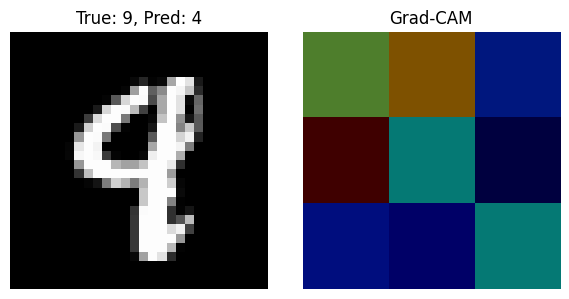

In [19]:
# Ensure predictions are available
# y_pred = model.predict(X_test)
# y_pred_classes = np.argmax(y_pred, axis=1)

mis_idx = np.where(y_pred_classes != y_test)[0][0]

img = X_test[mis_idx:mis_idx+1]  # keep batch dimension
true_label = y_test[mis_idx]
pred_label = y_pred_classes[mis_idx]

heatmap = make_gradcam_heatmap(img, model, last_conv_layer_name="conv2d_2")

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img[0].squeeze(), cmap="gray")
plt.title(f"True: {true_label}, Pred: {pred_label}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img[0].squeeze(), cmap="gray")
plt.imshow(heatmap, cmap="jet", alpha=0.5)
plt.title("Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()


In [20]:
baseline_params = basic_model.count_params()
cnn_params = model.count_params()

print("Baseline params:", baseline_params)
print("CNN params:", cnn_params)

efficiency_baseline = basic_acc / baseline_params
efficiency_cnn = test_accuracy / cnn_params

print("Baseline Efficiency:", efficiency_baseline)
print("CNN Efficiency:", efficiency_cnn)


Baseline params: 693962
CNN params: 242442
Baseline Efficiency: 1.4219798994364055e-06
CNN Efficiency: 4.105311765063504e-06


In [21]:
# import time

# # Baseline timing
# start = time.time()
# baseline_model = build_basic_model()
# baseline_model.fit(X_train, y_train_cat, epochs=5, verbose=0)
# baseline_time = time.time() - start

# # CNN timing
# start = time.time()
# model.fit(X_train, y_train_cat, epochs=5, verbose=0)
# cnn_time = time.time() - start

# print("Baseline Training Time:", baseline_time)
# print("CNN Training Time:", cnn_time)

import time

# Use a small subset for timing
X_small = X_train[:10000]
y_small = y_train_cat[:10000]

# Baseline timing (2 epochs on subset)
baseline_model = build_basic_model()
start = time.time()
baseline_model.fit(X_small, y_small, epochs=2, verbose=0)
baseline_time = time.time() - start

# CNN timing (2 epochs on subset)
start = time.time()
model.fit(X_small, y_small, epochs=2, verbose=0)
cnn_time = time.time() - start

print("Baseline Training Time (subset, 2 epochs):", baseline_time)
print("CNN Training Time (subset, 2 epochs):", cnn_time)



Baseline Training Time (subset, 2 epochs): 9.398155689239502
CNN Training Time (subset, 2 epochs): 19.880486488342285


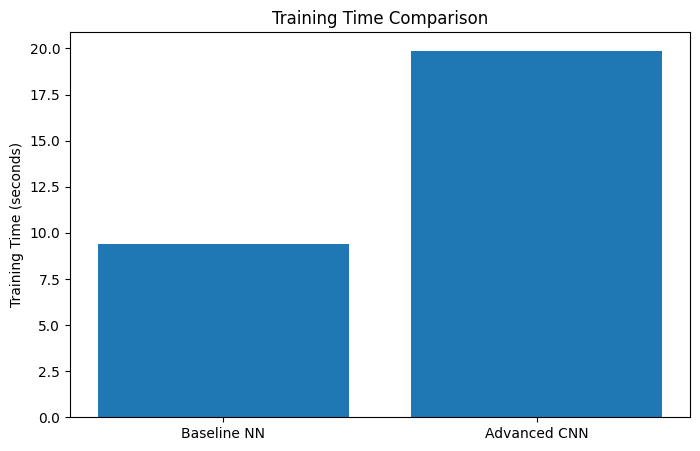

In [22]:
models = ["Baseline NN", "Advanced CNN"]
times = [baseline_time, cnn_time]

plt.figure(figsize=(8,5))
plt.bar(models, times)
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.show()


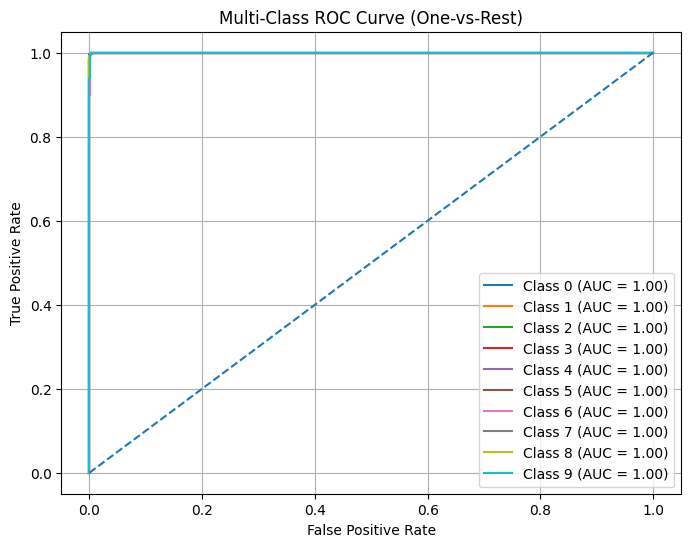

In [23]:
# Binarize labels
y_test_bin = label_binarize(y_test, classes=range(10))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(10):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(10):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()


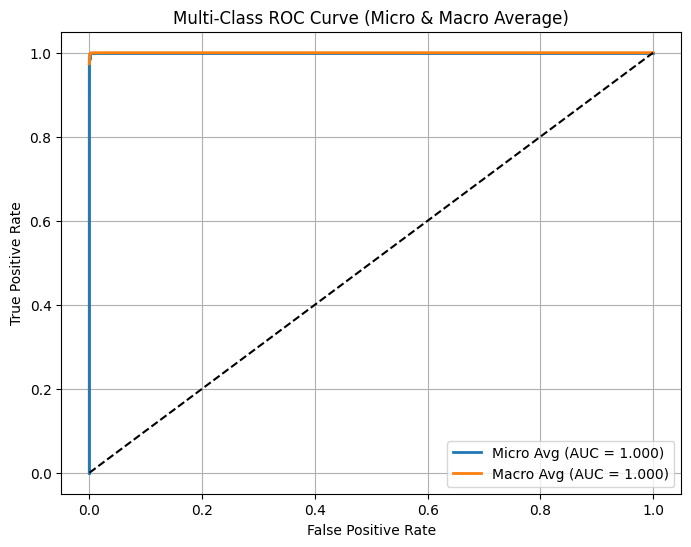

In [24]:
# Micro-average ROC curve
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(), 
    y_pred.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC curve
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(10):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= 10

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8,6))

for i in range(10):
    plt.plot(fpr[i], tpr[i], alpha=0.3)

plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro Avg (AUC = {roc_auc['micro']:.3f})",
         linewidth=2)

plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro Avg (AUC = {roc_auc['macro']:.3f})",
         linewidth=2)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (Micro & Macro Average)")
plt.legend()
plt.grid(True)
plt.show()


In [25]:
from tensorflow import keras
from tensorflow.keras import layers

def build_cnn_model(filters):
    model = keras.Sequential([
        layers.Conv2D(filters, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(filters*2, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(filters*4, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [26]:
import time

sizes = {
    "Small CNN": 16,
    "Medium CNN": 32,
    "Large CNN": 64
}

results = {}

for name, f in sizes.items():
    
    print(f"\nTraining {name}...")
    
    model_temp = build_cnn_model(f)
    
    start = time.time()
    model_temp.fit(X_train, y_train_cat,
                   epochs=3,
                   validation_data=(X_test, y_test_cat),
                   verbose=0)
    train_time = time.time() - start
    
    acc = model_temp.evaluate(X_test, y_test_cat, verbose=0)[1]
    params = model_temp.count_params()
    
    results[name] = {
        "accuracy": acc,
        "params": params,
        "time": train_time
    }
    
    print(f"{name} → Accuracy: {acc:.4f}, Params: {params}, Time: {train_time:.2f}s")



Training Small CNN...
Small CNN → Accuracy: 0.9850, Params: 56714, Time: 106.39s

Training Medium CNN...
Medium CNN → Accuracy: 0.9897, Params: 225034, Time: 104.51s

Training Large CNN...
Large CNN → Accuracy: 0.9924, Params: 896522, Time: 211.76s


In [27]:
results["Advanced CNN"] = {
    "accuracy": test_accuracy,
    "params": model.count_params(),
    "time": None
}


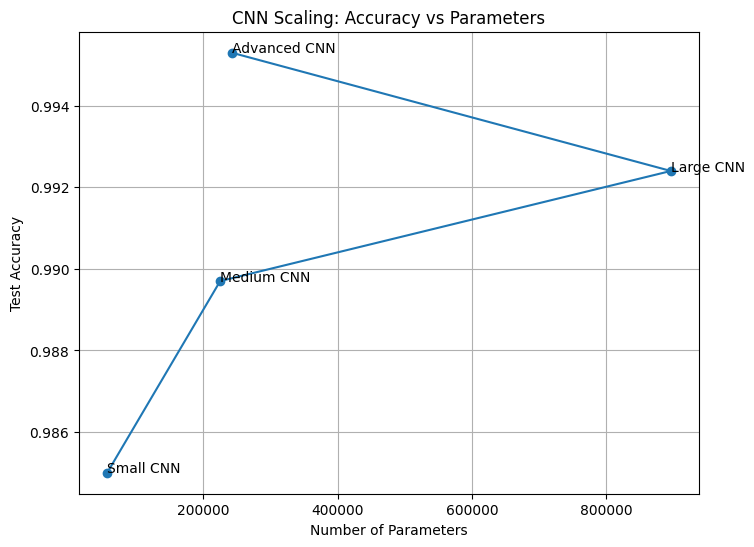

In [28]:
model_names = list(results.keys())
params = [results[m]["params"] for m in model_names]
accuracies = [results[m]["accuracy"] for m in model_names]

plt.figure(figsize=(8,6))
plt.plot(params, accuracies, marker='o')

for i, name in enumerate(model_names):
    plt.text(params[i], accuracies[i], name)

plt.xlabel("Number of Parameters")
plt.ylabel("Test Accuracy")
plt.title("CNN Scaling: Accuracy vs Parameters")
plt.grid(True)
plt.show()


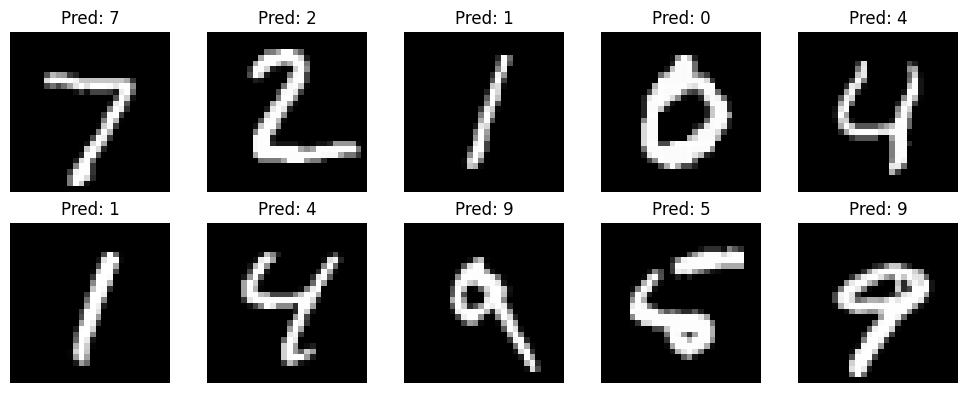

In [30]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred_classes[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
model.save("advanced_mnist_cnn_model.h5")


C:\Users\dell\anaconda3\envs\tf\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
